In [ ]:
import torch
import torch.nn as nn
import numpy as np
import sys
import os
import json
import itertools
import pandas as pd
import gc  # Added for memory cleanup
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Referencing your project structure verbatim
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP # Verbatim reference to architectures.py
from src.utils import set_seed, apply_heavy_tailed_init # Verbatim reference to utils.py

def save_physics_snapshot(model, input_batch, output_dir, t_idx, epoch, alpha, g):
    model.eval()

    # Capture physics data as before
    pre_acts = model.get_pre_activations(input_batch)
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    layer_physics = {}
    for idx, layer in enumerate(linear_layers):
        layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
        h = pre_acts[idx] if idx < len(linear_layers) - 1 else pre_acts["classifier"]

        # Compute Jacobian using float32 for precision
        W = layer.weight.data.float()
        d_act = 1.0 - torch.tanh(h).pow(2).float()
        D_avg = d_act.mean(dim=0)
        J = D_avg.unsqueeze(1) * W

        layer_physics[layer_key] = {
            "pre_activations": h.float().cpu(),
            "jacobian": J.cpu()
        }

    snapshot = {
        "metadata": {"task": t_idx + 1, "epoch": epoch, "alpha": alpha, "g": g},
        "state_dict": model.state_dict(), # Native PyTorch format
        "physics": layer_physics         # Your specific research metrics
    }

    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"snapshot_T{t_idx+1}_E{epoch}.pt"
    torch.save(snapshot, file_path)
    return file_path

def update_GPM_bases(model, images, threshold, feature_list=None):
    model.eval()
    with torch.no_grad():
        # reps contains h^1, h^2, ..., h^L
        reps = model.get_pre_activations(images)

    # 1. Prepare actual inputs (x^l) for each layer
    # Input to Layer 0 is raw pixels; Input to Layer l is phi(h^l)
    all_inputs = [images]
    for h in list(reps.values())[:-1]: # We don't need the final classifier output
        all_inputs.append(torch.tanh(h)) # Matches your activation_name="tanh"

    if feature_list is None:
        feature_list = [None] * len(all_inputs)

    for i, activation in enumerate(all_inputs):
        X = activation.cpu().numpy()
        # SVD on layer inputs to find principal components [cite: 154]
        U, S, Vh = np.linalg.svd(X, full_matrices=False)

        s_sq = S**2
        s_sum = np.sum(s_sq)
        k, current_sum = 0, 0
        for val in s_sq:
            current_sum += val
            k += 1
            if current_sum / s_sum >= threshold:
                break

        task_basis = Vh[:k].T # Shape: [in_features, k]

        if feature_list[i] is None:
            feature_list[i] = task_basis
        else:
            combined = np.concatenate((feature_list[i], task_basis), axis=1)
            U_new, _, _ = np.linalg.svd(combined, full_matrices=False)
            feature_list[i] = U_new[:, :min(combined.shape[0], combined.shape[1])]

    return feature_list

def apply_GPM_projection(model, feature_list):
    if feature_list is None:
        return

    # Extract all linear layers: Layer 0, 1, ..., Classifier
    layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    with torch.no_grad():
        for i, layer in enumerate(layers):
            # feature_list[i] is the basis for the input to layers[i]
            if i >= len(feature_list) or feature_list[i] is None:
                continue

            basis = torch.FloatTensor(feature_list[i]).to(layer.weight.device)
            grad = layer.weight.grad

            # Math: g_proj = g - (g @ B @ B.T) [Protects the old task subspace]
            proj_grad = grad - torch.mm(torch.mm(grad, basis), basis.t())
            layer.weight.grad.copy_(proj_grad)

In [53]:
# --- 1. CONFIGURATION ---
num_tasks = 5  # Standard for Split Fashion-MNIST (2 classes per task)
seed = 42
alpha_list = [2.0, 1.2]
g_list = [1.0, 3.0]
depth = 9
hidden_size = 784
bias = False
activation_name = "tanh"
optimiser = "sgd"
batch_size = 128
lr = 1e-3
epochs = 30
snapshot_epochs = [0, 14, 29]
GPM_THRESHOLD = 0.80

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. DATA LOADING & SPLITTING ---
def get_split_tasks(dataset, num_tasks=5):
    """Filters dataset into subsets of 2 classes per task."""
    imgs = torch.stack([img for img, _ in dataset]).to(device).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(device)

    task_bundles = []
    # Create 5 tasks: (0,1), (2,3), (4,5), (6,7), (8,9)
    for i in range(num_tasks):
        c1, c2 = 2*i, 2*i + 1
        mask = (lbls == c1) | (lbls == c2)
        task_bundles.append((imgs[mask], lbls[mask]))
    return task_bundles

print("Fast-loading Fashion-MNIST to GPU and splitting by class...")
f_train = datasets.FashionMNIST('../data', train=True, download=True, transform=transforms.ToTensor())
f_test = datasets.FashionMNIST('../data', train=False, download=True, transform=transforms.ToTensor())

# Pre-split the data into 5 tasks
train_tasks = get_split_tasks(f_train, num_tasks)
test_tasks = get_split_tasks(f_test, num_tasks)

# --- 3. GRID SWEEP EXECUTION ---
for alpha, g in itertools.product(alpha_list, g_list):
    set_seed(seed) # Assuming your set_seed function is defined globally
    run_name = f"split_fashion_alpha_{alpha}_g_{g}_lr_{lr}"
    output_dir = Path(f"./results_fashion_gpm{GPM_THRESHOLD}_fc{depth+1}/{run_name}")
    output_dir.mkdir(parents=True, exist_ok=True)

    # Metadata Logging
    config_params = {
        "alpha": alpha, "g": g, "seed": seed, "depth": depth,
        "hidden_size": hidden_size, "lr": lr, "batch_size": batch_size,
        "activation": activation_name, "num_tasks": num_tasks,
        "snapshot_epochs": snapshot_epochs, "bias": bias,
        "scenario": "Split Fashion-MNIST"
    }
    with open(output_dir / f"run_config_seed_{seed}.json", "w") as f:
        json.dump(config_params, f, indent=4)

    # Note: Ensure GeneralMLP and apply_heavy_tailed_init are available in your scope
    model = GeneralMLP(784, hidden_size, 10, depth, activation_name, bias=bias).to(device)
    apply_heavy_tailed_init(model, alpha=alpha, g=g, base_seed=seed)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    results_history = []

    gpm_feature_bases = None

    for t_idx in range(num_tasks):
        print(f"\n[{run_name}] --- Task {t_idx + 1} ---")
        curr_train_imgs, curr_train_lbls = train_tasks[t_idx]
        train_loader = DataLoader(TensorDataset(curr_train_imgs, curr_train_lbls),
                                 batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            model.train()
            total_train_loss, train_correct, train_total = 0, 0, 0
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()

                # --- NEW: GPM PROJECTION STEP ---
                if t_idx > 0: # No projection needed for first task
                    apply_GPM_projection(model, gpm_feature_bases)

                optimizer.step()

                total_train_loss += loss.item()
                train_correct += (outputs.argmax(1) == labels).sum().item()
                train_total += labels.size(0)

            # Snapshot saving (Capturing first batch of current task)
            if epoch in snapshot_epochs:
                save_physics_snapshot(model, curr_train_imgs[:batch_size],
                                     output_dir / "checkpoints", t_idx, epoch, alpha, g)

            # Evaluation phase: Check current and all previous tasks
            model.eval()
            epoch_metrics = {
                "alpha": alpha, "g": g, "epoch": epoch + 1, "task_id": t_idx + 1,
                "train_loss": total_train_loss / len(train_loader),
                "train_acc": train_correct / train_total,
            }

            # Pre-fill columns for all possible 5 tasks
            for i in range(num_tasks):
                epoch_metrics[f"task_{i+1}_acc"] = np.nan

            with torch.no_grad():
                for prev_t_idx in range(t_idx + 1):
                    val_imgs, val_lbls = test_tasks[prev_t_idx]
                    outputs = model(val_imgs)
                    acc = (outputs.argmax(1) == val_lbls).float().mean().item()
                    epoch_metrics[f"task_{prev_t_idx+1}_acc"] = acc

            results_history.append(epoch_metrics)

            # Live tracking printout
            print(f"Ep {epoch+1:02d} | T1: {epoch_metrics['task_1_acc']:.4f} | "
                  f"Curr: {epoch_metrics[f'task_{t_idx+1}_acc']:.4f} | Loss: {epoch_metrics['train_loss']:.4f}")

        # --- AFTER TASK COMPLETION: UPDATE GPM MEMORY ---
        print(f"Updating GPM memory for Task {t_idx+1}...")
        # Use a small subset (e.g., 300 samples) of the current task for SVD
        svd_samples = curr_train_imgs[:300]
        gpm_feature_bases = update_GPM_bases(model, svd_samples, GPM_THRESHOLD, gpm_feature_bases)

        # Log subspace sizes for your "Ruggedness" theory
        for i, b in enumerate(gpm_feature_bases):
            if b is not None:
                print(f"Layer {i} Subspace Rank: {b.shape[1]}")

    # Save and Cleanup
    df = pd.DataFrame(results_history)
    df.to_csv(output_dir / f"results_log_seed_{seed}.csv", index=False)

    del model, optimizer, results_history, df
    torch.cuda.empty_cache()
    gc.collect()

Fast-loading Fashion-MNIST to GPU and splitting by class...
Applying HT Init: alpha=2.0, g=1.0, seed=42

[split_fashion_alpha_2.0_g_1.0_lr_0.001] --- Task 1 ---
Ep 01 | T1: 0.9675 | Curr: 0.9675 | Loss: 0.2635
Ep 02 | T1: 0.9725 | Curr: 0.9725 | Loss: 0.0916
Ep 03 | T1: 0.9765 | Curr: 0.9765 | Loss: 0.0725
Ep 04 | T1: 0.9765 | Curr: 0.9765 | Loss: 0.0630
Ep 05 | T1: 0.9790 | Curr: 0.9790 | Loss: 0.0573
Ep 06 | T1: 0.9800 | Curr: 0.9800 | Loss: 0.0536
Ep 07 | T1: 0.9805 | Curr: 0.9805 | Loss: 0.0506
Ep 08 | T1: 0.9805 | Curr: 0.9805 | Loss: 0.0485
Ep 09 | T1: 0.9795 | Curr: 0.9795 | Loss: 0.0471
Ep 10 | T1: 0.9805 | Curr: 0.9805 | Loss: 0.0455
Ep 11 | T1: 0.9805 | Curr: 0.9805 | Loss: 0.0441
Ep 12 | T1: 0.9815 | Curr: 0.9815 | Loss: 0.0432
Ep 13 | T1: 0.9810 | Curr: 0.9810 | Loss: 0.0423
Ep 14 | T1: 0.9810 | Curr: 0.9810 | Loss: 0.0416
Ep 15 | T1: 0.9830 | Curr: 0.9830 | Loss: 0.0408
Ep 16 | T1: 0.9815 | Curr: 0.9815 | Loss: 0.0402
Ep 17 | T1: 0.9835 | Curr: 0.9835 | Loss: 0.0395
Ep 18 

Processed 1 successful seeds for α=2.0, g=1.0, lr=0.001
Processed 1 successful seeds for α=2.0, g=3.0, lr=0.001
Processed 1 successful seeds for α=1.2, g=1.0, lr=0.001
Processed 1 successful seeds for α=1.2, g=3.0, lr=0.001


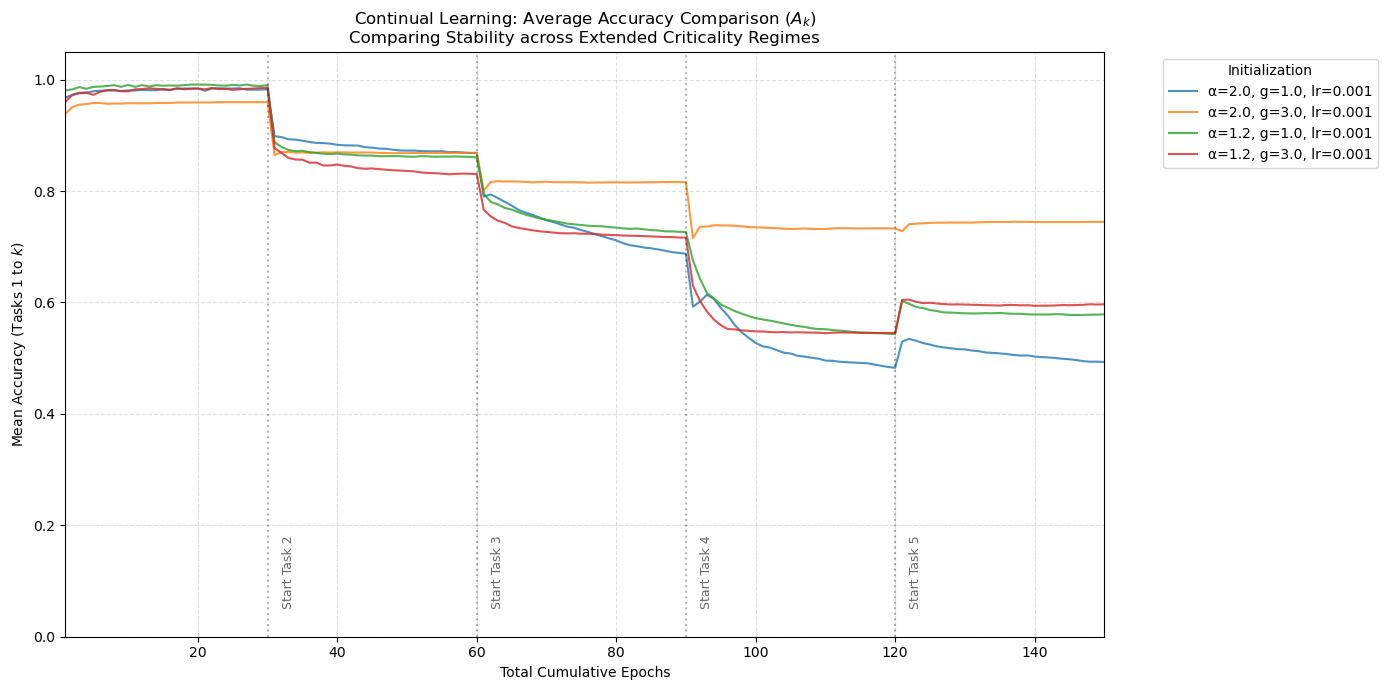

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fashion_gpm0.8_fc10")
task_success_threshold = 0.00  # Filter out "dead" seeds
num_tasks = 10

def plot_multiple_accuracies(param_pairs):
    """
    param_pairs: List of tuples [(alpha, g, lr), (alpha, g, lr), ...]
    """
    master_plot_data = []
    task_transition_epochs = None

    for alpha, g, lr in param_pairs:
        folder_name = f"split_fashion_alpha_{alpha}_g_{g}_lr_{lr}"
        folder_path = results_path / folder_name
        condition_label = f"α={alpha}, g={g}, lr={lr}"

        if not folder_path.exists():
            print(f"Skipping: {folder_path} (not found).")
            continue

        seed_count = 0
        for csv_file in folder_path.glob("results_log_seed_*.csv"):
            df = pd.read_csv(csv_file)

            # Trainability Filter: Ensure model successfully learned Task 1
            if df[df['task_id'] == 1]['task_1_acc'].max() < task_success_threshold:
                continue

            seed_count += 1

            # Calculate Mean Accuracy (Ak) for every cumulative epoch
            for idx, row in df.iterrows():
                current_task_id = int(row['task_id'])
                # Average only the tasks introduced so far
                task_cols = [f"task_{i}_acc" for i in range(1, current_task_id + 1)]
                mean_acc = row[task_cols].mean()

                master_plot_data.append({
                    "Total Epoch": idx + 1,
                    "Average Accuracy": mean_acc,
                    "Condition": condition_label,
                    "Seed": seed_count
                })

            # Capture transition points from the first successful seed
            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} successful seeds for {condition_label}")

    if not master_plot_data:
        print("No data found to plot.")
        return

    # Convert to DataFrame for Seaborn
    plot_df = pd.DataFrame(master_plot_data)

    # --- Plotting ---
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Average Accuracy",
        hue="Condition",
        errorbar="sd",
        alpha=0.8
    )

    # Vertical markers for Task transitions
    if task_transition_epochs:
        # Don't draw line for the final epoch
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
            plt.text(epoch_mark + 2, 0.05, f"Start Task {t_idx+2}",
                     fontsize=9, rotation=90, verticalalignment='bottom', alpha=0.6)

    plt.title("Continual Learning: Average Accuracy Comparison ($A_k$)\n"
              "Comparing Stability across Extended Criticality Regimes")
    plt.ylim(0, 1.05)
    plt.xlim(1, plot_df["Total Epoch"].max())
    plt.ylabel("Mean Accuracy (Tasks 1 to $k$)")
    plt.xlabel("Total Cumulative Epochs")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Initialization")
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Compare Gaussian Baseline vs various Heavy-Tailed setups[cite: 1]
comparison_list = [
    (2.0, 1.0, 0.001),  # Standard Gaussian Edge-of-Chaos[cite: 1]
    (2.0, 3.0, 0.001),  # Standard Gaussian Edge-of-Chaos[cite: 1]
    (1.2, 1.0, 0.001),  # Standard Gaussian Edge-of-Chaos[cite: 1]
    (1.2, 3.0, 0.001),  # Standard Gaussian Edge-of-Chaos[cite: 1]
]

plot_multiple_accuracies(comparison_list)

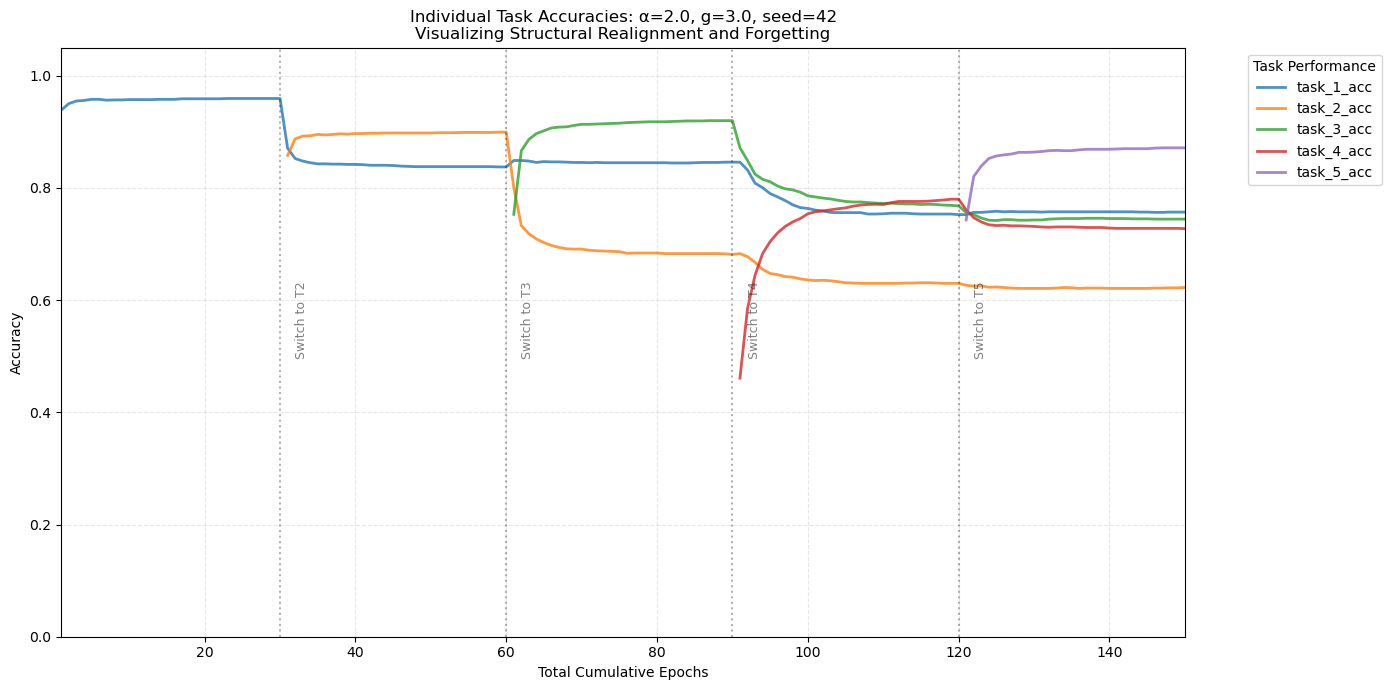

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fashion_gpm0.8_fc10")
num_tasks = 5

def plot_individual_task_curves(alpha, g, lr, seed=42):
    """
    Plots the individual task accuracy lines for a specific run.
    Helps identify the 'Warm Start' phenomenon and Catastrophic Forgetting.
    """
    folder_name = f"split_fashion_alpha_{alpha}_g_{g}_lr_{lr}"
    folder_path = results_path / folder_name
    csv_file = folder_path / f"results_log_seed_{seed}.csv"

    if not csv_file.exists():
        print(f"File not found: {csv_file}")
        return

    df = pd.read_csv(csv_file)

    # We need to melt the task columns into a long format for Seaborn
    # Columns are: [Total Epoch, task_1_acc, task_2_acc, ..., task_10_acc]
    task_cols = [f"task_{i}_acc" for i in range(1, num_tasks + 1)]

    # Track the cumulative epoch index (1 to 300 for 10 tasks x 30 epochs)
    df['Cumulative Epoch'] = range(1, len(df) + 1)

    # Melt data for plotting
    plot_df = df.melt(
        id_vars=['Cumulative Epoch'],
        value_vars=task_cols,
        var_name='Task',
        value_name='Accuracy'
    )

    # --- Plotting ---
    plt.figure(figsize=(14, 7))

    # Highlight the current task learning with a thicker line
    # Older tasks will appear as decaying curves[cite: 1, 2]
    sns.lineplot(
        data=plot_df,
        x="Cumulative Epoch",
        y="Accuracy",
        hue="Task",
        palette="tab10",
        linewidth=2,
        alpha=0.8
    )

    # Capture transition points for vertical lines
    task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

    for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
        plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
        plt.text(epoch_mark + 2, 0.5, f"Switch to T{t_idx+2}",
                 fontsize=9, rotation=90, alpha=0.5)

    plt.title(f"Individual Task Accuracies: α={alpha}, g={g}, seed={seed}\n"
              f"Visualizing Structural Realignment and Forgetting")
    plt.ylim(0, 1.05)
    plt.xlim(1, len(df))
    plt.ylabel("Accuracy")
    plt.xlabel("Total Cumulative Epochs")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Task Performance")
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Visualize the Heavy-Tailed run to inspect Task 1 'Rich Learning' vs Task 2 'Warm Start'
plot_individual_task_curves(alpha=2.0, g=3.0, lr=0.001, seed=42)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import sys
import os
import pandas as pd
from pathlib import Path

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROBE_EPOCHS = 30
BATCH_SIZE = 1024
# Updated Path: Targeting the final task of the Split Fashion experiment
SNAPSHOT_PATH = Path("./results_fashion_fc10/split_fashion_alpha_1.2_g_1.0_lr_0.001/checkpoints/snapshot_T5_E29.pt")
OUTPUT_CSV = Path("../results/continual_learning") / "fashion_layerwise_probe_results.csv"

# Architecture params
DEPTH = 9
HIDDEN_SIZE = 128
INPUT_SIZE = 784
NUM_CLASSES = 10
BIAS = False

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# --- 2. DATA PREPARATION (FASHION-MNIST) ---
def get_gpu_loader(train=True):
    # Fashion-MNIST mean/std are typically (0.2860,), (0.3530,)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))
    ])
    dataset = datasets.FashionMNIST(root='../data', train=train, download=True, transform=transform)

    # Pre-loading to GPU for maximum speed during probing
    all_data = torch.stack([img for img, _ in dataset]).to(DEVICE).view(-1, 784)
    all_targets = torch.tensor([label for _, label in dataset]).to(DEVICE)
    return DataLoader(TensorDataset(all_data, all_targets), batch_size=BATCH_SIZE, shuffle=train)

print("Preloading Fashion-MNIST to GPU...")
train_loader = get_gpu_loader(train=True)
test_loader = get_gpu_loader(train=False)

# --- 3. LOADING BACKBONE ---
# Ensure GeneralMLP is imported from your src.architectures
from src.architectures import GeneralMLP

model = GeneralMLP(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES, DEPTH, bias=BIAS).to(DEVICE)

if SNAPSHOT_PATH.exists():
    checkpoint = torch.load(SNAPSHOT_PATH, map_location=DEVICE)
    if "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        # Robust fallback for your specific checkpoint naming conventions
        new_state_dict = {}
        linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
        for idx, layer in enumerate(linear_layers):
            layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
            weight_data = checkpoint["layers"][layer_key]["weights"].to(torch.float32)
            for name, param in model.named_parameters():
                if param.shape == weight_data.shape and "weight" in name and name not in new_state_dict:
                    new_state_dict[name] = weight_data
                    break
        model.load_state_dict(new_state_dict, strict=False)
    print(f"Weights loaded from: {SNAPSHOT_PATH}")
else:
    raise FileNotFoundError(f"Missing snapshot at {SNAPSHOT_PATH}")

# Freeze the backbone completely
model.eval()
for param in model.parameters():
    param.requires_grad = False

# --- 4. LAYERWISE PROBING LOOP ---
all_layer_data = []

# Probe the pre-activations to determine feature dimensions
with torch.no_grad():
    dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
    pre_acts = model.get_pre_activations(dummy)

layer_keys = list(pre_acts.keys()) if isinstance(pre_acts, dict) else range(len(pre_acts))

for layer_idx in layer_keys:
    print(f"\n--- Probing Layer {layer_idx} ---")

    with torch.no_grad():
        dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
        feature_dim = model.get_pre_activations(dummy)[layer_idx].shape[1]

    # The Probe: A simple linear mapping to 10 classes
    probe = nn.Linear(feature_dim, NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(probe.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(PROBE_EPOCHS):
        probe.train()
        running_loss = 0.0

        for data, target in train_loader:
            with torch.no_grad():
                # Extracting static features from the frozen backbone
                feats = model.get_pre_activations(data)[layer_idx]

            optimizer.zero_grad()
            loss = criterion(probe(feats), target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluation on the Full Test Set (all 10 classes)
        probe.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                feats = model.get_pre_activations(data)[layer_idx]
                correct += probe(feats).argmax(dim=1).eq(target).sum().item()

        epoch_acc = (correct / 10000.0) # Accuracy on the 10k test samples
        avg_loss = running_loss / len(train_loader)

        all_layer_data.append({
            "layer": layer_idx,
            "epoch": epoch + 1,
            "loss": avg_loss,
            "accuracy": epoch_acc
        })

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:<10.4f} | Acc: {epoch_acc*100:.2f}%")

# --- 5. SAVE ---
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df = pd.DataFrame(all_layer_data)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nFull trajectory saved to: {OUTPUT_CSV}")

In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- 1. CONFIGURATION ---
# Point this to the root of your alpha directory
BASE_PATH = Path("./results_fashion_fc10/split_fashion_alpha_2.0_g_3.0_lr_0.001/checkpoints")
OUTPUT_CSV = Path("../results/subspace_alignment_alpha_2.0.csv")
K_DIM = 10  # The rank of the subspace we are tracking (top 50 singular vectors)

def get_top_singular_vectors(weight_matrix, k):
    """Performs SVD and returns the top k left singular vectors (U)."""
    # Use left singular vectors (U) to see how output feature directions align
    # Or right (Vh) to see how input sensitivities align. We'll use U here.
    U, S, Vh = torch.linalg.svd(weight_matrix, full_matrices=False)
    return U[:, :k]

def calculate_grassmann_distance(U1, U2):
    """Calculates the Grassmannian distance between two k-dimensional subspaces."""
    # Cosines of principal angles (singular values of U1.T @ U2)
    mat = torch.matmul(U1.t(), U2)
    # Clamp to avoid precision issues with sqrt
    cos_sq = torch.linalg.svdvals(mat)**2
    # Grassmannian distance is the L2 norm of the principal angles (arcsin(sin))
    # Or more simply for small angles: sqrt(k - sum(cos^2))
    k = U1.shape[1]
    dist_sq = k - torch.sum(cos_sq)
    return torch.sqrt(torch.clamp(dist_sq, min=0.0)).item()

# --- 2. EXECUTION ---
results = []

# We compare everything against Task 1 as the 'Reference Subspace'
ref_task = 1
ref_path = BASE_PATH / f"snapshot_T{ref_task}_E29.pt"
ref_checkpoint = torch.load(ref_path, map_location='cpu')

# Target a specific layer (e.g., Layer 2 or 3 where HT divergence was highest)
target_layer_key = "features.2.weight" # Adjust based on your state_dict keys

# Extract weight matrix from checkpoint
# Note: Check your checkpoint structure; if using GeneralMLP state_dict:
# ref_w = ref_checkpoint["state_dict"]["layers.2.weight"]
# Using your fallback logic from before:
ref_w = ref_checkpoint["state_dict"][target_layer_key].to(torch.float32)
U_ref = get_top_singular_vectors(ref_w, K_DIM)

print(f"Tracking drift of {target_layer_key} from Task 1 Subspace...")

for t in range(1, 11):
    task_path = BASE_PATH / f"snapshot_T{t}_E29.pt"

    if not task_path.exists():
        continue

    checkpoint = torch.load(task_path, map_location='cpu')
    current_w = checkpoint["state_dict"][target_layer_key].to(torch.float32)
    U_curr = get_top_singular_vectors(current_w, K_DIM)

    distance = calculate_grassmann_distance(U_ref, U_curr)

    print(f"Task {t} Grassmann Distance: {distance:.4f}")
    results.append({
        "task": t,
        "distance": distance,
        "k": K_DIM
    })

# --- 3. SAVE ---
df = pd.DataFrame(results)
df.to_csv(OUTPUT_CSV, index=False)
print(f"Subspace alignment saved to {OUTPUT_CSV}")